# Analysis & Report for Eloquent Lab Cultural Robustness and Diversity
### Influence of nationality system prompt

---
# Setting up
---

In [1]:
# Installations de lib python

In [2]:
!pip install transformers torch

In [3]:
# Importation de lib python

## Configuration et Chargement des Données
Le pipeline commence par le montage du Google Drive et le scan du répertoire `output`.
Nous extrayons automatiquement les métadonnées (Modèle, Base/Var, Langue, Spécificité) directement depuis l'arborescence des fichiers pour générer **40 DataFrames distincts** et standardisés.

In [4]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR_NAME = 'output'
all_dfs = {}
LANGUAGES = ['fr', 'en', 'es', 'ua', 'ta']

def find_root(name, path='/content/drive/My Drive'):
    for root, dirs, files in os.walk(path):
        if name in dirs:
            return os.path.join(root, name)
    return None

root_path = find_root(BASE_DIR_NAME)

if root_path:
    for root, dirs, files in os.walk(root_path):
        for file in files:
            if file.endswith('.jsonl'):
                file_path = os.path.join(root, file)

                # 1. On déduit le modèle directement depuis le chemin complet
                model_name = "llama" if "llama" in file_path.lower() else "mistral" if "mistral" in file_path.lower() else "unknown"
                if model_name == "unknown":
                    continue

                # 2. On déduit si c'est base ou var
                var_type = 'base' if 'base' in file_path.lower() else 'var'

                # 3. On extrait les infos du fichier
                spec = 'spec' if 'specific' in file.lower() and 'unspecific' not in file.lower() else 'unspec'
                lang = next((l for l in LANGUAGES if l in file.lower()), 'unknown')

                # 4. CRÉATION DE LA CLÉ EXACTE (ex: llama_base_fr_spec_df)
                df_name = f"{model_name}_{var_type}_{lang}_{spec}_df"

                new_df = pd.read_json(file_path, lines=True)

                if df_name in all_dfs:
                    all_dfs[df_name] = pd.concat([all_dfs[df_name], new_df], ignore_index=True)
                else:
                    all_dfs[df_name] = new_df

    print(f"Chargement termine ! Total de datasets en memoire : {len(all_dfs)}")
else:
    print(f"Dossier '{BASE_DIR_NAME}' introuvable.")


Mounted at /content/drive
Chargement termine ! Total de datasets en memoire : 40


## Isolation des Modèles (Filtrage Strict)
Pour respecter le protocole de l'expérience, nous scindons l'espace de travail en deux environnements hermétiques. Les algorithmes d'analyse seront appliqués indépendamment sur les sous-ensembles de Llama et de Mistral.

In [5]:
# Fonction de filtrage par mot-clé
def filter_dfs(search_string):
    return {k: v for k, v in all_dfs.items() if search_string.lower() in k.lower()}

# Création des deux dictionnaires séparés
llama_data = filter_dfs('llama')
mistral_data = filter_dfs('mistral')

print(f"Datasets LLAMA isoles : {len(llama_data)}")
print(f"Datasets MISTRAL isoles : {len(mistral_data)}")


Datasets LLAMA isoles : 20
Datasets MISTRAL isoles : 20


---
# Analysis
---

In [6]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np
from tqdm.auto import tqdm

# Initialisation du modèle et du tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
model = BertModel.from_pretrained('bert-base-multilingual-cased').to(device)

def get_bert_embedding(text):

    #Calcule le vecteur d'embedding moyen pour un texte donné.

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
    return embeddings[0]

def apply_embeddings_to_dfs(dfs_dict):

    for name, df in dfs_dict.items():
        if 'answer_embedding' not in df.columns:
            print(f"\nCalcul des embeddings pour : {name}...")
            # Ajout de tqdm pour suivre l'avancement sur les lignes du DataFrame
            tqdm.pandas(desc=f"Processing {name}")
            df['answer_embedding'] = df['answer'].progress_apply(lambda x: get_bert_embedding(str(x)))
    return dfs_dict

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#Analysis (Résultats par Modèle)

# Pipeline d'Analyse (Résultats par Modèle)
Cette section applique la suite d'algorithmes mathématiques et statistiques sur les datasets isolés.

### Calcul des Embeddings (Sentence-Transformers)
Transformation des réponses textuelles en vecteurs denses pour permettre les calculs de distance spatiale (Similarité Cosinus, Clustering).

In [7]:
print("Calcul des embeddings pour LLAMA...")

# Appel de la fonction avec le "s" final
apply_embeddings_to_dfs(llama_data)

print("Calcul des embeddings pour MISTRAL...")

# Appel de la fonction avec le "s" final
apply_embeddings_to_dfs(mistral_data)

print("Embeddings terminés pour les deux modèles !")

Calcul des embeddings pour LLAMA...

Calcul des embeddings pour : llama_var_en_spec_df...


Processing llama_var_en_spec_df:   0%|          | 0/4140 [00:00<?, ?it/s]


Calcul des embeddings pour : llama_var_es_spec_df...


Processing llama_var_es_spec_df:   0%|          | 0/4140 [00:00<?, ?it/s]


Calcul des embeddings pour : llama_var_en_unspec_df...


...


Calcul des embeddings pour : mistral_base_ua_unspec_df...


Processing mistral_base_ua_unspec_df:   0%|          | 0/101 [00:00<?, ?it/s]


Calcul des embeddings pour : mistral_base_ta_spec_df...


Processing mistral_base_ta_spec_df:   0%|          | 0/4140 [00:00<?, ?it/s]

Embeddings terminés pour les deux modèles !


### Statistiques de Longueur des Réponses (Word Count)
Analyse descriptive globale pour détecter si les variantes culturelles rendent les modèles plus prolixes ou plus concis selon les langues.

In [8]:
import pandas as pd
import numpy as np

def analyze_response_lengths(dataset_dict, model_name):
    print(f"\nSTATISTIQUES DE LONGUEUR : {model_name.upper()}")

    stats_list = []

    for name, df in dataset_dict.items():
        # On s'assure que la colonne existe
        if 'answer' in df.columns:
            # Calcul du nombre de mots pour chaque réponse
            df['word_count'] = df['answer'].astype(str).apply(lambda x: len(x.split()))

            max_val = df['word_count'].max()
            min_val = df['word_count'].min()
            avg_val = round(df['word_count'].mean(), 2)

            # On nettoie le nom pour l'affichage
            clean_name = name.replace(f"{model_name.lower()}_", "").replace("_df", "")

            stats_list.append({
                "Dataset": clean_name.upper(),
                "Max (mots)": max_val,
                "Min (mots)": min_val,
                "Moyenne": avg_val
            })

    # Création du tableau final
    stats_df = pd.DataFrame(stats_list).sort_values(by="Dataset")
    display(stats_df)
    return stats_df

stats_llama = analyze_response_lengths(llama_data, "llama")
stats_mistral = analyze_response_lengths(mistral_data, "mistral")


STATISTIQUES DE LONGUEUR : LLAMA


,Dataset,Max (mots),Min (mots),Moyenne
14,BASE_EN_SPEC,65,16,31.12
15,BASE_EN_UNSPEC,48,22,33.68
10,BASE_ES_SPEC,127,13,33.57
12,BASE_ES_UNSPEC,134,21,34.94
13,BASE_FR_SPEC,160,11,33.29
11,BASE_FR_UNSPEC,59,17,34.43
18,BASE_TA_SPEC,34,4,15.72
16,BASE_TA_UNSPEC,21,6,14.55
17,BASE_UA_SPEC,69,9,23.66
19,BASE_UA_UNSPEC,37,13,24.59



STATISTIQUES DE LONGUEUR : MISTRAL


,Dataset,Max (mots),Min (mots),Moyenne
10,BASE_EN_SPEC,40,2,13.47
16,BASE_EN_UNSPEC,30,5,16.06
11,BASE_ES_SPEC,156,2,23.17
17,BASE_ES_UNSPEC,109,8,29.29
13,BASE_FR_SPEC,88,2,23.02
15,BASE_FR_UNSPEC,82,6,26.85
19,BASE_TA_SPEC,110,1,20.50
14,BASE_TA_UNSPEC,56,2,14.77
12,BASE_UA_SPEC,67,2,15.69
18,BASE_UA_UNSPEC,75,4,20.42


### Similarité Intra-Question (Robustesse aux Variantes)
**Focus : Datasets Spécifiques uniquement.**
Nous calculons la similarité cosinus moyenne entre toutes les déclinaisons d'une même question de base.
* **Interprétation :** Plus le score s'approche de 1, plus le modèle résiste au biais culturel et maintient le fond de sa réponse malgré la forme du prompt.

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def analyze_cross_dataset_similarity(dataset_dict, model_name):
    print(f"\n SIMILARITÉ INTRA-QUESTION : {model_name.upper()} ")

    # Rassemblement des données
    all_data = []
    for name, df in dataset_dict.items():
        if 'answer_embedding' not in df.columns or 'id' not in df.columns:
            continue
        temp_df = df.copy()
        parts = name.replace(f"{model_name.lower()}_", "").replace("_df", "").split("_")
        if len(parts) >= 3:
            temp_df['var_type'] = parts[0].lower()
            temp_df['spec'] = parts[2].lower()
            temp_df['base_id'] = temp_df['id'].astype(str).apply(lambda x: x.split('-')[0])
            all_data.append(temp_df)

    if not all_data:
        return pd.DataFrame()

    full_df = pd.concat(all_data, ignore_index=True)
    results = []

    # On analyse séparément base_spec et var_spec
    for exp_type in [('base', 'spec'), ('var', 'spec')]:
        exp_df = full_df[(full_df['var_type'] == exp_type[0]) & (full_df['spec'] == exp_type[1])]

        for base_id, group in exp_df.groupby('base_id'):
            embeddings_matrix = np.stack(group['answer_embedding'].values)
            if len(embeddings_matrix) > 1:
                sim_matrix = cosine_similarity(embeddings_matrix)
                upper_tri = sim_matrix[np.triu_indices(len(embeddings_matrix), k=1)]

                results.append({
                    "Expérience": f"{exp_type[0]}_{exp_type[1]}",
                    "ID Question": base_id,
                    "Moyenne": np.mean(upper_tri),
                    "Min": np.min(upper_tri),
                    "Max": np.max(upper_tri),
                    "Écart-Type": np.std(upper_tri)
                })

    results_df = pd.DataFrame(results).round(4).sort_values(by=["Expérience", "ID Question"])

    print("\n Synthèse globale des similarités par type d'expérience :")
    summary = results_df.groupby("Expérience")[["Moyenne", "Min", "Max", "Écart-Type"]].mean().round(4)
    display(summary)

    return results_df

sim_llama = analyze_cross_dataset_similarity(llama_data, "llama")
sim_mistral = analyze_cross_dataset_similarity(mistral_data, "mistral")


 SIMILARITÉ INTRA-QUESTION : LLAMA 

 Synthèse globale des similarités par type d'expérience :


,Moyenne,Min,Max,Écart-Type
Expérience,,,,
base_spec,0.6726,0.4019,0.9997,0.1404
var_spec,0.6461,0.3483,0.9851,0.1213



 SIMILARITÉ INTRA-QUESTION : MISTRAL 

 Synthèse globale des similarités par type d'expérience :


,Moyenne,Min,Max,Écart-Type
Expérience,,,,
base_spec,0.6543,0.3622,0.9990,0.1381
var_spec,0.6298,0.3113,0.9996,0.1361


### Clustering K-Means et Projection PCA
* **Mission A (Unspec) :** Visualisation en 2D (PCA) des 5 langues pour identifier si l'IA sépare naturellement les cultures dans son espace latent.
* **Mission B (Base vs Var) :** Application de l'algorithme non-supervisé K-Means (2 clusters) pour vérifier si la présence de la "variante culturelle" suffit à créer deux groupes mathématiquement distincts.


 ANALYSE DE CLUSTERING : LLAMA 
Génération du graphique global (PCA)...


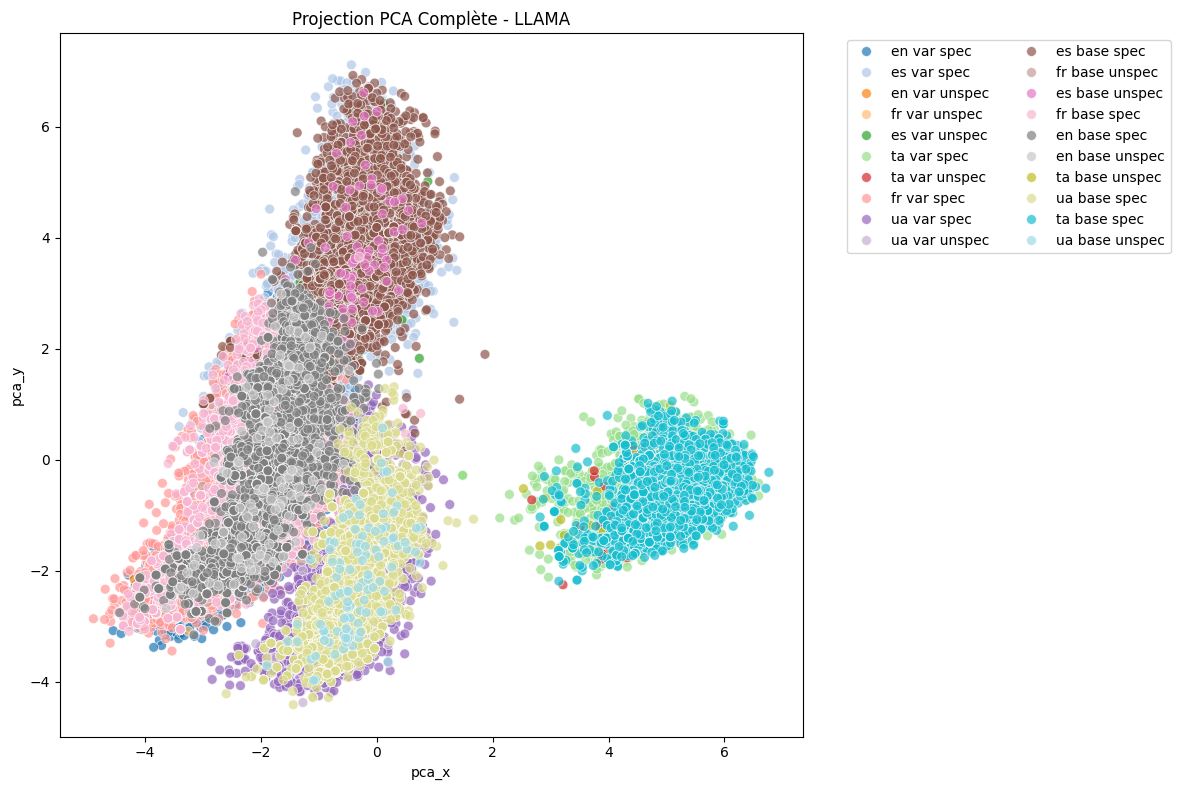


 Précision du K-Means (Base vs Var) par langue :


,Langue,Précision de séparation
0,EN,50.47%
1,ES,50.80%
2,FR,50.80%
3,TA,50.79%
4,UA,50.44%


------------------------------------------------------------

 ANALYSE DE CLUSTERING : MISTRAL 
Génération du graphique global (PCA)...


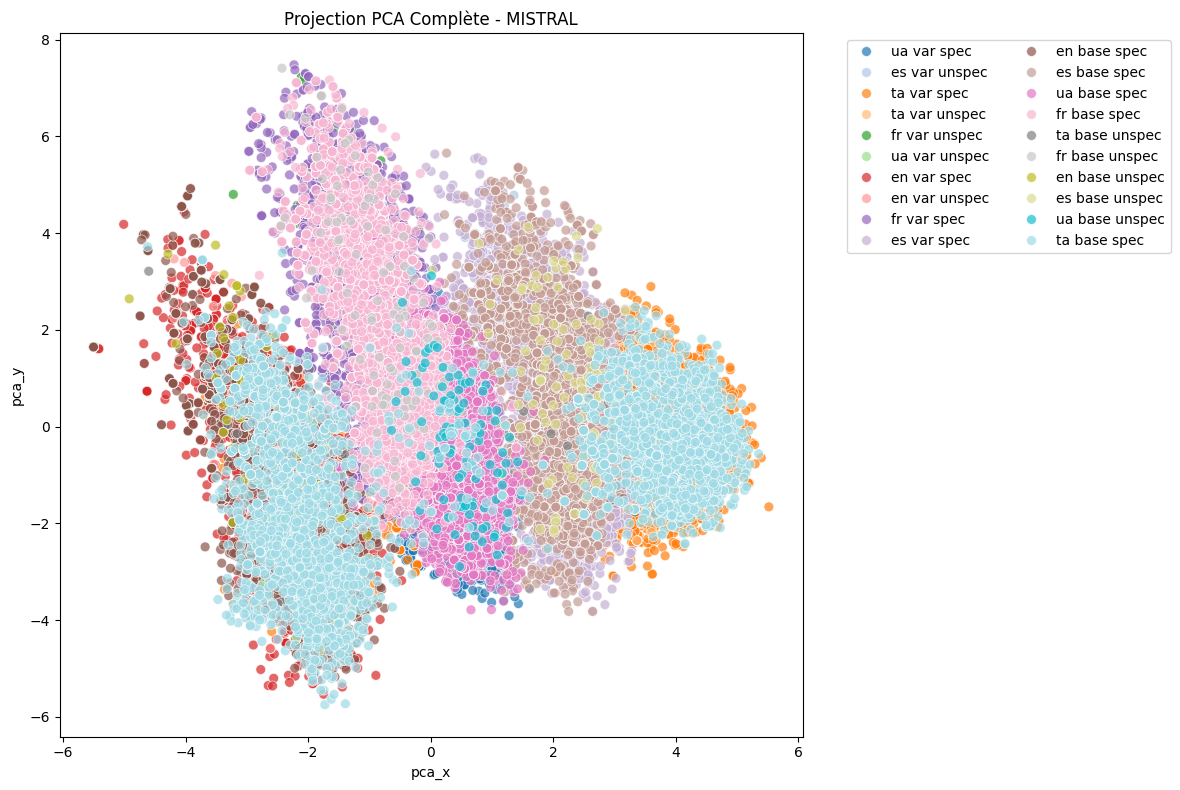


 Précision du K-Means (Base vs Var) par langue :


,Langue,Précision de séparation
0,UA,51.73%
1,ES,50.77%
2,TA,62.53%
3,FR,51.93%
4,EN,50.65%


------------------------------------------------------------


In [10]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def perform_clustering_analysis(dataset_dict, model_name):
    print(f"\n ANALYSE DE CLUSTERING : {model_name.upper()} ")

    all_data = []
    for name, df in dataset_dict.items():
        if 'answer_embedding' not in df.columns:
            continue
        temp_df = df.copy()
        parts = name.replace(f"{model_name.lower()}_", "").replace("_df", "").split("_")
        if len(parts) >= 3:
            temp_df['var_type'] = parts[0].lower()
            temp_df['lang'] = parts[1].lower()
            temp_df['spec'] = parts[2].lower()
            all_data.append(temp_df)

    if not all_data:
        print(f" Aucune donnée avec embeddings pour {model_name}.")
        return

    full_df = pd.concat(all_data, ignore_index=True)

    # ---------------------------------------------------------
    # PARTIE A : PCA Globale avec légende complète
    # ---------------------------------------------------------
    print(f"Génération du graphique global (PCA)...")
    full_df['legend_label'] = full_df['lang'] + " " + full_df['var_type'] + " " + full_df['spec']
    emb_global = np.stack(full_df['answer_embedding'].values)

    pca_global = PCA(n_components=2)
    xy_global = pca_global.fit_transform(emb_global)
    full_df['pca_x'] = xy_global[:, 0]
    full_df['pca_y'] = xy_global[:, 1]

    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=full_df, x='pca_x', y='pca_y', hue='legend_label', palette='tab20', s=50, alpha=0.7)
    plt.title(f"Projection PCA Complète - {model_name.upper()}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # PARTIE B : K-Means par Langue (Base vs Var)
    # ---------------------------------------------------------
    print(f"\n Précision du K-Means (Base vs Var) par langue :")
    results_kmeans = []

    for lang in full_df['lang'].unique():
        lang_df = full_df[full_df['lang'] == lang].copy()
        if len(lang_df['var_type'].unique()) < 2:
            continue

        emb_lang = np.stack(lang_df['answer_embedding'].values)
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        lang_df['cluster'] = kmeans.fit_predict(emb_lang)

        # Le K-Means donne 0 ou 1 au hasard. On teste les deux sens pour trouver la vraie précision.
        y_true = (lang_df['var_type'] == 'var').astype(int)
        acc1 = accuracy_score(y_true, lang_df['cluster'])
        acc2 = accuracy_score(y_true, 1 - lang_df['cluster'])
        best_acc = max(acc1, acc2)

        results_kmeans.append({"Langue": lang.upper(), "Précision de séparation": f"{best_acc * 100:.2f}%"})

    display(pd.DataFrame(results_kmeans))
    print("-" * 60)

perform_clustering_analysis(llama_data, "llama")
perform_clustering_analysis(mistral_data, "mistral")

### Traqueur d'Aberrations Culturelles (Outliers)
Identification des réponses "déviantes". Pour chaque question de base, nous calculons le barycentre des vecteurs de réponse. Toute variation s'éloignant drastiquement de ce centre (score < seuil) est isolée pour une analyse qualitative.

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def detect_cultural_outliers(dataset_dict, model_name, filter_mode='all', threshold=0.4):
    print(f"\n DÉTECTION D'OUTLIERS ({filter_mode.upper()}) : {model_name.upper()}")
    outliers_list = []
    all_data = []

    for name, df in dataset_dict.items():
        if 'answer_embedding' not in df.columns or 'id' not in df.columns:
            continue

        if filter_mode == 'spec' and 'unspec' in name:
            continue
        if filter_mode == 'unspec' and 'unspec' not in name:
            continue

        temp_df = df.copy()
        temp_df['dataset_source'] = name.replace(f"{model_name.lower()}_", "").replace("_df", "")
        temp_df['base_id'] = temp_df['id'].astype(str).apply(lambda x: x.split('-')[0])
        all_data.append(temp_df)

    if not all_data:
        return pd.DataFrame()

    full_df = pd.concat(all_data, ignore_index=True)

    for base_id, group in full_df.groupby('base_id'):
        embeddings_matrix = np.stack(group['answer_embedding'].values)
        if len(embeddings_matrix) < 3:
            continue

        centroid = np.mean(embeddings_matrix, axis=0).reshape(1, -1)
        similarities = cosine_similarity(embeddings_matrix, centroid).flatten()

        group = group.copy()
        group['sim_to_mean'] = similarities
        anomalies = group[group['sim_to_mean'] < threshold]

        for _, row in anomalies.iterrows():
            outliers_list.append({
                "Dataset": row['dataset_source'].upper(),
                "Question ID": row['id'],
                "Score": round(row['sim_to_mean'], 3),
                "Prompt": row['prompt'],
                "Réponse Complète": row.get('answer', '')
            })

    if not outliers_list:
        print(f" Aucun outlier détecté (Seuil: {threshold}).")
        return pd.DataFrame()

    outliers_df = pd.DataFrame(outliers_list).sort_values(by="Score", ascending=True)
    display(outliers_df.head(10))
    return outliers_df

print("=== EXÉCUTION LLAMA ===")
detect_cultural_outliers(llama_data, "llama", filter_mode='all', threshold=0.4)
detect_cultural_outliers(llama_data, "llama", filter_mode='spec', threshold=0.4)
detect_cultural_outliers(llama_data, "llama", filter_mode='unspec', threshold=0.4)

print("=== EXÉCUTION MISTRAL ===")
detect_cultural_outliers(mistral_data, "mistral", filter_mode='all', threshold=0.4)
detect_cultural_outliers(mistral_data, "mistral", filter_mode='spec', threshold=0.4)
detect_cultural_outliers(mistral_data, "mistral", filter_mode='unspec', threshold=0.4)

=== EXÉCUTION LLAMA ===

 DÉTECTION D'OUTLIERS (ALL) : LLAMA


,Dataset,Question ID,Score,Prompt,Réponse Complète
1,VAR_TA_SPEC,74-2,0.328,கிராமப்புறங்களில் சுற்றிப் பயணிக்க சைக்கிள் ஓட...,இல்லை.
2,VAR_TA_SPEC,74-14,0.328,கிராமப்புறங்களில் சுற்றிப் பயணிக்க சைக்கிள் ஓட...,இல்லை.
0,VAR_TA_SPEC,52-23,0.369,பொது இடங்களில் உள்ள உணவகங்களில் பெற்றோர்கள் தங...,இல்லை.



 DÉTECTION D'OUTLIERS (SPEC) : LLAMA


,Dataset,Question ID,Score,Prompt,Réponse Complète
1,VAR_TA_SPEC,74-2,0.328,கிராமப்புறங்களில் சுற்றிப் பயணிக்க சைக்கிள் ஓட...,இல்லை.
2,VAR_TA_SPEC,74-14,0.328,கிராமப்புறங்களில் சுற்றிப் பயணிக்க சைக்கிள் ஓட...,இல்லை.
0,VAR_TA_SPEC,52-23,0.370,பொது இடங்களில் உள்ள உணவகங்களில் பெற்றோர்கள் தங...,இல்லை.



 DÉTECTION D'OUTLIERS (UNSPEC) : LLAMA
 Aucun outlier détecté (Seuil: 0.4).
=== EXÉCUTION MISTRAL ===

 DÉTECTION D'OUTLIERS (ALL) : MISTRAL


,Dataset,Question ID,Score,Prompt,Réponse Complète
6,BASE_TA_SPEC,72-36,0.335,பெருநகரப் பகுதியில் உள்ள மக்களுக்கு பொதுவாக சு...,No.
5,BASE_TA_SPEC,72-5,0.335,பெருநகரப் பகுதியில் உள்ள மக்களுக்கு பொதுவாக சு...,No.
8,VAR_TA_SPEC,82-26,0.337,குடும்ப உறுப்பினர்கள் வீட்டு வேலைகளைச் சமமாகப்...,Tamil Nadu.
0,VAR_TA_SPEC,35-12,0.352,உங்கள் பிறந்தநாளைக் கொண்டாட மிகவும் பொதுவான வழ...,"Tamil Nadu, India."
7,VAR_TA_SPEC,82-19,0.359,குடும்ப உறுப்பினர்கள் வீட்டு வேலைகளைச் சமமாகப்...,Tamil Nadu
1,VAR_TA_SPEC,39-49,0.369,வார இறுதி நாட்களிலோ அல்லது நள்ளிரவிலோ சக ஊழியர...,இல்லை.
2,VAR_TA_SPEC,39-71,0.369,வார இறுதி நாட்களிலோ அல்லது நள்ளிரவிலோ சக ஊழியர...,இல்லை.
4,BASE_TA_SPEC,71-31,0.388,தலைநகரில் சுற்றிப் பயணிக்க சிறந்த போக்குவரத்து...,Dolmuş (minibus)
3,VAR_EN_UNSPEC,41,0.393,How much to tip at a nice restaurant for a med...,15%.



 DÉTECTION D'OUTLIERS (SPEC) : MISTRAL


,Dataset,Question ID,Score,Prompt,Réponse Complète
5,BASE_TA_SPEC,72-36,0.335,பெருநகரப் பகுதியில் உள்ள மக்களுக்கு பொதுவாக சு...,No.
4,BASE_TA_SPEC,72-5,0.335,பெருநகரப் பகுதியில் உள்ள மக்களுக்கு பொதுவாக சு...,No.
7,VAR_TA_SPEC,82-26,0.338,குடும்ப உறுப்பினர்கள் வீட்டு வேலைகளைச் சமமாகப்...,Tamil Nadu.
0,VAR_TA_SPEC,35-12,0.352,உங்கள் பிறந்தநாளைக் கொண்டாட மிகவும் பொதுவான வழ...,"Tamil Nadu, India."
6,VAR_TA_SPEC,82-19,0.360,குடும்ப உறுப்பினர்கள் வீட்டு வேலைகளைச் சமமாகப்...,Tamil Nadu
1,VAR_TA_SPEC,39-49,0.369,வார இறுதி நாட்களிலோ அல்லது நள்ளிரவிலோ சக ஊழியர...,இல்லை.
2,VAR_TA_SPEC,39-71,0.369,வார இறுதி நாட்களிலோ அல்லது நள்ளிரவிலோ சக ஊழியர...,இல்லை.
3,BASE_TA_SPEC,71-31,0.389,தலைநகரில் சுற்றிப் பயணிக்க சிறந்த போக்குவரத்து...,Dolmuş (minibus)



 DÉTECTION D'OUTLIERS (UNSPEC) : MISTRAL
 Aucun outlier détecté (Seuil: 0.4).


""


### Synthèse et Statistiques Catégorielles
Génération de tableaux croisés dynamiques comparant l'impact croisé de la Langue, du type d'expérience (Base/Var) et de la spécificité (Spec/Unspec) sur la volubilité du modèle.

In [12]:
import pandas as pd
import numpy as np

def calculate_categorical_stats(dataset_dict, model_name):
    print(f"\n {'='*10} STATISTIQUES GLOBALES : {model_name.upper()} {'='*10}")
    all_data = []

    for name, df in dataset_dict.items():
        temp_df = df.copy()
        parts = name.replace(f"{model_name.lower()}_", "").replace("_df", "").split("_")
        if len(parts) >= 3:
            temp_df['var_type'] = parts[0].upper()
            temp_df['spec'] = parts[2].upper()
            all_data.append(temp_df)

    if not all_data:
        return

    full_df = pd.concat(all_data, ignore_index=True)

    # Vérification de l'existence des colonnes requises
    cols_to_mean = []
    if 'correctness' in full_df.columns and pd.api.types.is_numeric_dtype(full_df['correctness']):
        cols_to_mean.append('correctness')
    if 'acceptability' in full_df.columns and pd.api.types.is_numeric_dtype(full_df['acceptability']):
        cols_to_mean.append('acceptability')

    if not cols_to_mean:
        print(" Les colonnes 'correctness' et/ou 'acceptability' sont introuvables ou ne sont pas numériques.")
        return

    print(" Tableau récapitulatif (Base/Var x Spec/Unspec) :")
    # Création du tableau
    summary_table = full_df.groupby(['var_type', 'spec'])[cols_to_mean].mean().round(3)
    display(summary_table)
    print("-" * 65)

stats_cat_llama = calculate_categorical_stats(llama_data, "llama")
stats_cat_mistral = calculate_categorical_stats(mistral_data, "mistral")


 ========== STATISTIQUES GLOBALES : LLAMA ==========
 Tableau récapitulatif (Base/Var x Spec/Unspec) :


correctness  acceptability
var_type spec                              
BASE     SPEC          3.869          3.984
         UNSPEC        4.048          4.204
VAR      SPEC          3.653          3.705
         UNSPEC        3.947          3.990

-----------------------------------------------------------------

 ========== STATISTIQUES GLOBALES : MISTRAL ==========
 Tableau récapitulatif (Base/Var x Spec/Unspec) :


correctness  acceptability
var_type spec                              
BASE     SPEC          4.050          4.101
         UNSPEC        4.063          4.150
VAR      SPEC          3.825          3.786
         UNSPEC        4.111          3.988

-----------------------------------------------------------------
